### Importing libraries and modules

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize, differential_evolution
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ All packages imported successfully!")

✅ All packages imported successfully!


In [20]:
df = pd.read_csv('/kaggle/input/datasets/tungalavenkata/bluemountainds/machine_1_failures-2.csv')   # ← change filename
times = np.sort(df['FailureTimeDays'].values)
n     = len(times)
T     = times[-1]

### Exponential Model

In [21]:
# --- Goel-Okumoto (GO) ---
# m(t)  = a * (1 - exp(-b*t))
# λ(t)  = a*b * exp(-b*t)
def go_m(t, a, b):
    return a * (1.0 - np.exp(-b * t))

def go_lambda(t, a, b):
    return a * b * np.exp(-b * t)

### S shaped Perfect Debugging

In [22]:
# --- Delayed S-shaped (DS) ---
# m(t)  = a * (1 - (1 + b*t) * exp(-b*t))
# λ(t)  = a * b^2 * t * exp(-b*t)
def ds_m(t, a, b):
    return a * (1.0 - (1.0 + b * t) * np.exp(-b * t))

def ds_lambda(t, a, b):
    return a * (b ** 2) * t * np.exp(-b * t)

### Imperfect Debugging

In [23]:
# --- Yamada Imperfect Debugging Type-1 (YI1) ---
# m(t)  = (a / (1-α)) * (1 - exp(-b*(1-α)*t))
# λ(t)  = a*b * exp(-b*(1-α)*t)
def yi1_m(t, a, b, alpha):
    alpha = min(alpha, 0.9999)
    return (a / (1.0 - alpha)) * (1.0 - np.exp(-b * (1.0 - alpha) * t))

def yi1_lambda(t, a, b, alpha):
    alpha = min(alpha, 0.9999)
    return a * b * np.exp(-b * (1.0 - alpha) * t)

### Imperfect Debugging S shaped

In [24]:
# --- PNZ Model ---
# m(t)  = a * (1 - exp(-b*t)) * (1 - c/(c+1) * exp(-d*t))
# λ(t)  = a * exp(-b*t) * [b*(1 - c/(c+1)*exp(-d*t)) + (c*d/(c+1))*(1-exp(-b*t))]
def pnz_m(t, a, b, c, d):
    return a * (1.0 - np.exp(-b * t)) * (1.0 - (c / (c + 1.0)) * np.exp(-d * t))

def pnz_lambda(t, a, b, c, d):
    exp_bt = np.exp(-b * t)
    exp_dt = np.exp(-d * t)
    term1 = b * (1.0 - (c / (c + 1.0)) * exp_dt)
    term2 = (c * d / (c + 1.0)) * (1.0 - exp_bt)
    return a * exp_bt * (term1 + term2)

In [25]:
MODELS = {
    'Goel-Okumoto':       {'m': go_m,   'lam': go_lambda,   'params': ['a','b'],         'x0': [50., 0.05],            'bounds': [(1e-6,1e5),(1e-8,10.)]},
    'Delayed-S':          {'m': ds_m,   'lam': ds_lambda,   'params': ['a','b'],         'x0': [50., 0.05],            'bounds': [(1e-6,1e5),(1e-8,10.)]},
    'Yamada-Imperfect-1': {'m': yi1_m,  'lam': yi1_lambda,  'params': ['a','b','alpha'], 'x0': [50., 0.05, 0.1],       'bounds': [(1e-6,1e5),(1e-8,10.),(0.,0.999)]},
    'PNZ':                {'m': pnz_m,  'lam': pnz_lambda,  'params': ['a','b','c','d'], 'x0': [50., 0.05, 1.0, 0.05], 'bounds': [(1e-6,1e5),(1e-8,10.),(0.01,100),(1e-8,10.)]},
}

colors = {
    'Goel-Okumoto':       '#1f77b4',
    'Delayed-S':          '#ff7f0e',
    'Yamada-Imperfect-1': '#2ca02c',
    'PNZ':                '#d62728'
}

print("✅ 4 NHPP models defined!")

✅ 4 NHPP models defined!


In [26]:
def log_likelihood(params, times, m_func, lam_func):
    try:
        T       = float(times[-1])
        lambdas = np.array([lam_func(t, *params) for t in times], dtype=float)
        if np.any(lambdas <= 0) or np.any(~np.isfinite(lambdas)):
            return 1e99
        m_T = float(m_func(T, *params))
        if not np.isfinite(m_T) or m_T < 0:
            return 1e99
        return -(np.sum(np.log(lambdas)) - m_T)
    except Exception:
        return 1e99

def fit_model(times, model_cfg, use_de=True):
    times    = np.sort(np.asarray(times, dtype=float))
    m_func   = model_cfg['m']
    lam_func = model_cfg['lam']
    bounds   = model_cfg['bounds']
    x0       = model_cfg['x0']
    n        = len(times)

    neg_ll   = lambda p: log_likelihood(p, times, m_func, lam_func)
    best_res = None

    if use_de:
        res_de   = differential_evolution(neg_ll, bounds, seed=42,
                                          maxiter=2000, tol=1e-8,
                                          mutation=(0.5, 1.5), popsize=20)
        best_res = res_de

    x_start   = best_res.x if (best_res is not None and best_res.success) else x0
    res_local = minimize(neg_ll, x_start, method='L-BFGS-B', bounds=bounds,
                         options={'maxiter': 5000, 'ftol': 1e-12})
    if best_res is None or res_local.fun < best_res.fun:
        best_res = res_local

    p        = best_res.x
    ll       = -best_res.fun
    cum_emp  = np.arange(1, n + 1, dtype=float)
    cum_pred = np.array([m_func(t, *p) for t in times])
    mse      = np.mean((cum_emp - cum_pred) ** 2)
    rmse     = np.sqrt(mse)

    return {
        'params':  p,
        'loglik':  ll,
        'MSE':     mse,
        'RMSE':    rmse,
        'success': best_res.success,
    }

print("✅ MLE fitting functions ready!")

✅ MLE fitting functions ready!


### Maximum Likelihood Estimation

In [27]:
results = {}
for name, cfg in MODELS.items():
    print(f"Fitting {name}...", end='  ')
    res = fit_model(times, cfg, use_de=True)
    results[name] = res
    status = '✅' if res['success'] else '⚠️'
    print(f"{status}  LogLik={res['loglik']:.4f}  RMSE={res['RMSE']:.4f}")

print("\n✅ All models fitted!")

Fitting Goel-Okumoto...  ✅  LogLik=-121.7660  RMSE=29.8077
Fitting Delayed-S...  ✅  LogLik=-83.8376  RMSE=10.4201
Fitting Yamada-Imperfect-1...  ✅  LogLik=-121.7660  RMSE=29.8076
Fitting PNZ...  ✅  LogLik=1649.5701  RMSE=46.2592

✅ All models fitted!


In [33]:
rows = []
for name, res in results.items():
    cfg = MODELS[name]
    param_str = ', '.join([
        f"{pn}={pv:.6g}"
        for pn, pv in zip(cfg['params'], res['params'])
    ])
    
    rows.append({
        'Model':      name,
        '#Params':    len(cfg['params']),
        'Parameters': param_str,
        'LogLik':     round(res['loglik'], 4),
    })

summary_df = pd.DataFrame(rows).sort_values('LogLik', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

best_model_name = summary_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

             Model  #Params                               Parameters    LogLik
               PNZ        4 a=383.919, b=0.00631777, c=99.9999, d=10 1649.5701
         Delayed-S        2                   a=301.321, b=0.0314923  -83.8376
      Goel-Okumoto        2                   a=310.443, b=0.0140948 -121.7660
Yamada-Imperfect-1        3    a=163.084, b=0.0268304, alpha=0.47467 -121.7660
Best model: PNZ


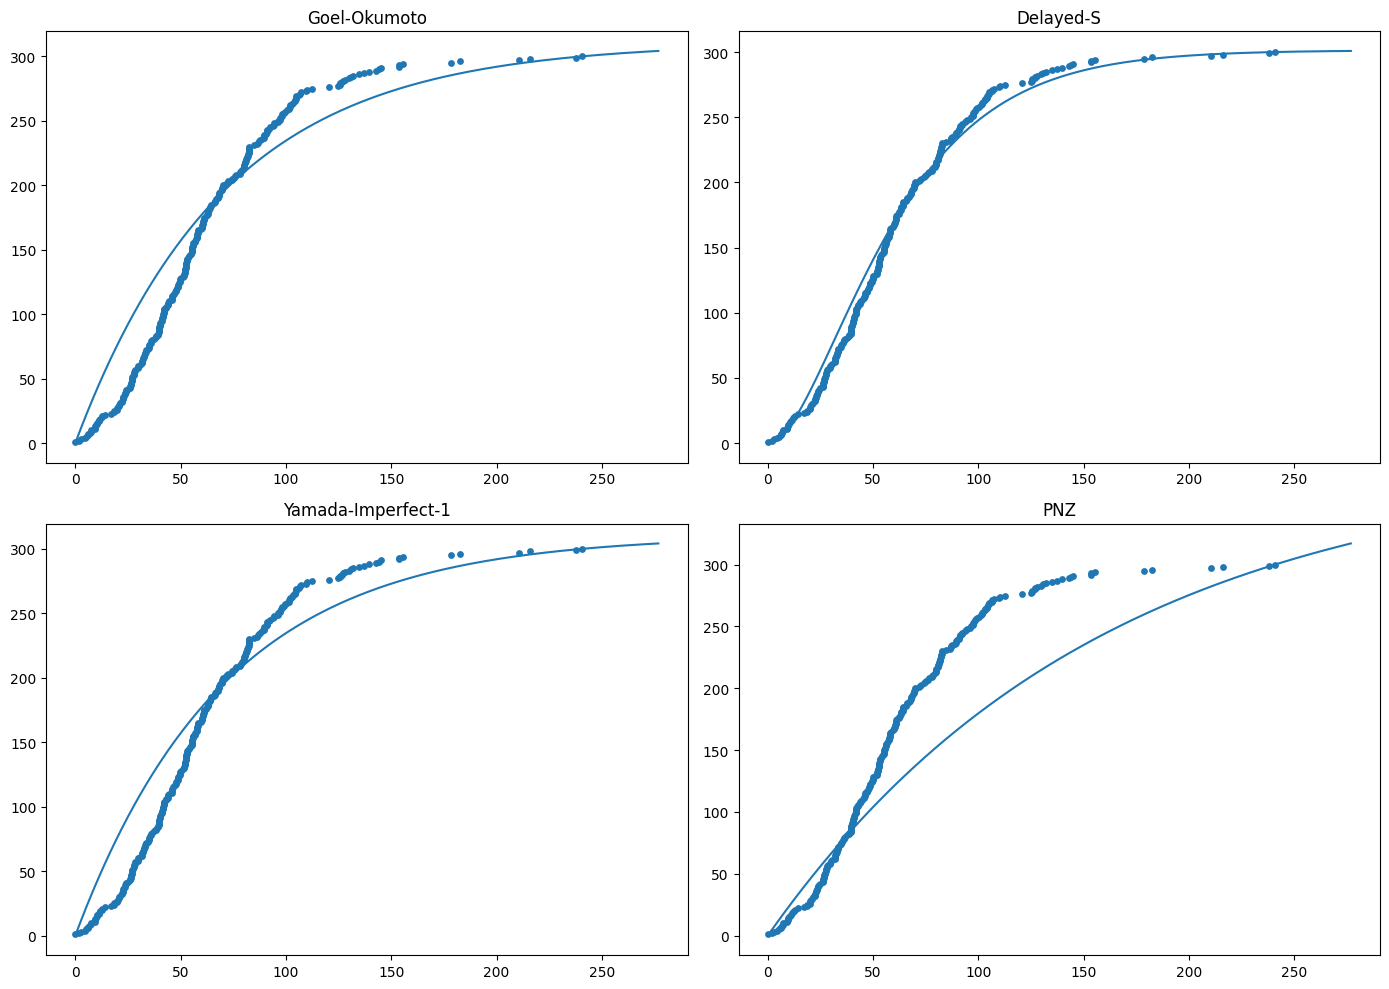

In [29]:
t_plot  = np.linspace(0.01, T * 1.15, 500)
emp_cum = np.arange(1, n + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, res) in zip(axes.flat, results.items()):
    m_func = MODELS[name]['m']
    p      = res['params']
    m_plot = [m_func(t, *p) for t in t_plot]

    ax.scatter(times, emp_cum, s=15)
    ax.plot(t_plot, m_plot)
    ax.set_title(name)

plt.tight_layout()
plt.show()